# Preparación del Entorno: Instalación de Dependencias

**¿Qué hace este código?**
Instala mediante `pip` las librerías necesarias para ejecutar modelos Transformer, aplicar técnicas de Parameter-Efficient Fine-Tuning (LoRA) y optimizar hiperparámetros.

**¿Por qué es necesario?**
Entornos de desarrollo como Jupyter o Google Colab no incluyen por defecto librerías avanzadas como `peft` (necesaria para LoRA) u `optuna` (para la búsqueda automatizada de hiperparámetros). Instalarlas al inicio garantiza que el resto del cuaderno se ejecute sin errores de "módulo no encontrado" (ModuleNotFoundError). La librería `accelerate` es un requisito del `Trainer` de Hugging Face para optimizar el uso de la CPU/GPU durante el entrenamiento.

In [ ]:
# Instalación de las librerías clave para el proyecto
!pip install -q transformers peft optuna accelerate

# Fase 1: Preprocesamiento y Adaptación de Datos

## 1.1 Importación de librerías
**¿Qué hace este código?** Importa las herramientas necesarias para la manipulación de datos (`pandas`), la codificación de las etiquetas (`LabelEncoder` de scikit-learn) y la tokenización del modelo (`AutoTokenizer` de la librería `transformers`).

**¿Por qué es necesario?**
Necesitamos `pandas` para estructurar nuestros tweets en una tabla manejable (DataFrame). Scikit-learn nos facilitará la conversión de categorías de texto a números, y la librería `transformers` es esencial para adaptar el texto al formato exacto que requerirá nuestro modelo.

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer
import torch

## 1.2 Carga del dataset original
**¿Qué hace este código?**
Abre el archivo de texto `Tweets.txt`, lee línea por línea y separa cada registro utilizando el delimitador `|`. Luego, guarda esta información en un DataFrame de pandas con dos columnas: `Categoria` y `Texto`.

**¿Por qué es necesario?**
El dataset en bruto es un archivo de texto plano.Para poder alimentar a nuestro modelo de aprendizaje profundo de forma estructurada con nuestros 200 tweets (50 por categoría), primero debemos aislar claramente cuál es la etiqueta y cuál es el contenido del tweet.

In [ ]:
import pandas as pd
import re

# --- FUNCIÓN DE LIMPIEZA PARA TRANSFORMERS ---
def limpiar_tweet(texto):
    # 1. Quitamos las URLs
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto, flags=re.MULTILINE)
    # 2. Quitamos las menciones (ej: @SpotifyKR)
    texto = re.sub(r'@\w+', '', texto)
    # 3. Quitamos los saltos de línea y dejamos solo un espacio entre palabras
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# --- CARGA DEL DATASET ORIGINAL ---
datos = []
categorias_validas = ["Fórmula 1", "MotoGP", "Elden Ring", "Blackpink"]

with open('Tweets.txt', 'r', encoding='utf-8') as file:
    for line in file:
        if line.strip():
            partes = line.split('|', 1)

            if len(partes) == 2:
                categoria = partes[0].strip()
                texto_sucio = partes[1].strip()

                # Filtramos las clases válidas
                if categoria in categorias_validas and texto_sucio != "":
                    # Aquí aplicamos la limpieza
                    texto_limpio = limpiar_tweet(texto_sucio)

                    # Lo guardamos solo si tras limpiar no se ha quedado vacío
                    if texto_limpio != "":
                        datos.append({'Categoria': categoria, 'Texto': texto_limpio})

# Creamos el DataFrame
df = pd.DataFrame(datos)

# Mostramos cómo ha quedado de limpio
print("Recuento de tweets limpios:")
print(df['Categoria'].value_counts())
display(df.head())

Recuento de tweets limpios:
Categoria
Fórmula 1     50
MotoGP        50
Elden Ring    50
Blackpink     50
Name: count, dtype: int64


,Categoria,Texto
0,Fórmula 1,GEORGE RUSSELL IS ON POLE POSITION IN AUSTRALI...
1,Fórmula 1,George Russell reflects on a commanding qualif...
2,Fórmula 1,Our first Ghost Car of 2026! 👻 See where the f...
3,Fórmula 1,"""It's Max!"" 😱 Verstappen's Qualifying crash, a..."
4,Fórmula 1,Power. Slide. 🛝 Kimi Antonelli was certainly n...


## 1.3 Transformación de las etiquetas a formato numérico
**¿Qué hace este código?**
Toma la columna `Categoria` (que contiene strings como 'Fórmula 1', 'MotoGP', etc.) y le asigna un valor numérico único (0, 1, 2, 3) a cada clase utilizando `LabelEncoder`. El resultado se guarda en una nueva columna llamada `label`.

**¿Por qué es necesario?**
Las arquitecturas de redes neuronales y los modelos Transformer no entienden el texto en las variables objetivo.Requieren que las etiquetas estén en formato numérico para poder calcular matemáticamente la función de pérdida (loss function) durante el entrenamiento.

In [ ]:
# Inicializamos el codificador
le = LabelEncoder()

# Transformamos las etiquetas de texto a números enteros
df['label'] = le.fit_transform(df['Categoria'])

# Verificamos la correspondencia entre el texto y el número
mapeo_etiquetas = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapeo de etiquetas:", mapeo_etiquetas)

Mapeo de etiquetas: {'Blackpink': np.int64(0), 'Elden Ring': np.int64(1), 'Fórmula 1': np.int64(2), 'MotoGP': np.int64(3)}


## 1.4 Tokenización específica para el Transformer
**¿Qué hace este código?**
Instancia un tokenizador pre-entrenado (`bert-base-multilingual-cased`). Luego, procesa todos los textos de los tweets aplicando truncamiento (cortar si son muy largos), *padding* (rellenar si son muy cortos) y convirtiendo el resultado en tensores de PyTorch (`return_tensors='pt'`).

**¿Por qué es necesario?**
Los modelos Transformer no leen palabras, leen números.La tokenización específica es un paso obligatorio para transformar nuestro texto en los `input_ids` (el vocabulario numérico) y los `attention_mask` (que le dicen al modelo qué tokens son texto real y cuáles son relleno) que requiere el modelo elegido.

In [ ]:
# Definimos el modelo base que usaremos más adelante.
# Elegimos un modelo multilingüe dado que hay tweets en inglés, español y japonés.
modelo_base = "bert-base-multilingual-cased"

# Cargamos el tokenizador correspondiente a nuestra arquitectura
tokenizer = AutoTokenizer.from_pretrained(modelo_base)

# Convertimos los textos del dataframe a una lista
textos = df['Texto'].tolist()

# Aplicamos la tokenización
tokens = tokenizer(
    textos,
    padding=True,       # Rellena los tweets cortos para que tengan la misma longitud
    truncation=True,    # Corta los tweets que superen la longitud máxima del modelo
    max_length=128,     # Un tamaño de 128 es más que suficiente para tweets
    return_tensors='pt' # Devuelve tensores de PyTorch
)

print("Formato de los input_ids (Tensores):", tokens['input_ids'].shape)
print("Ejemplo de un texto tokenizado (input_ids del primer tweet):")
print(tokens['input_ids'][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Formato de los input_ids (Tensores): torch.Size([200, 117])
Ejemplo de un texto tokenizado (input_ids del primer tweet):
tensor([  101, 62997, 42622, 58719,   155, 32612, 39039, 82834, 40214, 49339,
          153, 39272, 11259,   153, 21793, 37611, 52980, 36351, 29088, 32995,
        29990, 11369, 35976,   106,   100,   160, 58132, 11090,   119,   138,
          119, 29079, 11127,   106,   100,   108, 27985,   108, 18290, 74450,
          102,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,

# Fase 2: Elección de la Arquitectura

## 2.1 Justificación del modelo base seleccionado
**¿Qué hace este código?**
Instancia la arquitectura de clasificación de secuencias basada en el modelo `bert-base-multilingual-cased`, adaptando su "cabeza" (la última capa de la red neuronal) para que tenga exactamente 4 salidas (nuestras 4 categorías).

**¿Por qué es necesario?**
El ejercicio requiere elegir y justificar un modelo base. Hemos elegido **mBERT (Multilingual BERT)** por la naturaleza de nuestro dataset. Al revisar los tweets, observamos texto en español, inglés e incluso caracteres japoneses. Un modelo entrenado exclusivamente en inglés no capturaría bien la semántica de todos los datos.
Además, la función `AutoModelForSequenceClassification` reemplaza automáticamente la cabeza de preentrenamiento original por una nueva capa lineal inicializada al azar, configurada para nuestras 4 etiquetas específicas. Esto es el núcleo del *Fine-Tuning*.

In [ ]:
from transformers import AutoModelForSequenceClassification

# Definimos el número de categorías (Fórmula 1, MotoGP, Elden Ring, Blackpink)
num_etiquetas = len(df['label'].unique())

# Cargamos el modelo pre-entrenado adaptando la cabeza de clasificación
modelo = AutoModelForSequenceClassification.from_pretrained(
    modelo_base,
    num_labels=num_etiquetas
)

print(f"Modelo cargado y configurado para {num_etiquetas} clases.")

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo cargado y configurado para 4 clases.


# Fase 3: Configuración del Entrenamiento (Fine-Tuning)

## 3.1 Creación del Dataset de PyTorch y división Train/Test
**¿Qué hace este código?**
Primero, divide nuestros datos en un conjunto de entrenamiento (80%) y uno de validación/test (20%). Luego, envuelve los tensores de PyTorch (los `input_ids` y `attention_mask` que generamos en la Fase 1) junto con las etiquetas numéricas dentro de una clase personalizada `TweetDataset`.

**¿Por qué es necesario?**
La librería Hugging Face (y PyTorch en general) necesita una estructura de datos estandarizada para poder iterar sobre ella en pequeños lotes (*batches*) durante el ciclo de entrenamiento. Si no empaquetamos los datos en una clase tipo `Dataset`, el entrenador no sabrá cómo inyectar los datos en el modelo.

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
import torch

# Dividimos el dataset (80% entrenamiento, 20% validación)
X_train_text, X_val_text, y_train, y_val = train_test_split(
    df['Texto'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42, stratify=df['label'].tolist()
)

# Tokenizamos por separado train y val
train_encodings = tokenizer(X_train_text, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(X_val_text, truncation=True, padding=True, max_length=128)

# Creamos la clase Dataset
class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Instanciamos los datasets
train_dataset = TweetDataset(train_encodings, y_train)
val_dataset = TweetDataset(val_encodings, y_val)

## 3.2 Configuración y ejecución del ciclo de entrenamiento
**¿Qué hace este código?**
Define los hiperparámetros iniciales del entrenamiento usando `TrainingArguments` (tamaño de lote, número de épocas, directorio de guardado) y lanza el proceso de ajuste fino utilizando la clase `Trainer`.

**¿Por qué es necesario?**
Esta es la ejecución real del *Fine-Tuning*.`Trainer` automatiza el bucle de entrenamiento, el cálculo de la pérdida (loss) y la actualización de los pesos del modelo sin tener que escribir todo el código matemático a mano. Iniciamos con 3 épocas y un *batch size* pequeño (8) por defecto, que luego optimizaremos en la siguiente fase.

In [ ]:
from transformers import Trainer, TrainingArguments

# Definimos los argumentos básicos del entrenamiento
training_args = TrainingArguments(
    output_dir='./resultados_tweets',
    num_train_epochs=3,              # Número de pasadas completas por los datos
    per_device_train_batch_size=8,   # Cantidad de datos procesados a la vez
    per_device_eval_batch_size=8,
    eval_strategy="epoch",           # Evaluamos al final de cada época
    save_strategy="epoch",
    logging_steps=10,
    learning_rate=2e-5,              # Tasa de aprendizaje inicial estándar
    load_best_model_at_end=True      # Se queda con el mejor modelo según validación
)

# Inicializamos el Trainer
trainer = Trainer(
    model=modelo,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

# Ejecutamos el Fine-Tuning
print("Iniciando el entrenamiento...")
trainer.train()

Iniciando el entrenamiento...


Epoch,Training Loss,Validation Loss
1,1.119232,0.930161
2,0.736194,0.578604
3,0.534281,0.459474


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=60, training_loss=0.8676307121912639, metrics={'train_runtime': 69.7068, 'train_samples_per_second': 6.886, 'train_steps_per_second': 0.861, 'total_flos': 28860512129280.0, 'train_loss': 0.8676307121912639, 'epoch': 3.0})

# Fase 4: Mejora de Hiperparámetros

## 4.1 Implementación de LoRA (Low-Rank Adaptation)
**¿Qué hace este código?**
Utiliza la librería `peft` para aplicar LoRA a nuestro modelo base multilingüe. Configuramos LoRA para que se aplique a las capas de atención (`query` y `value`), reduciendo drásticamente la cantidad de parámetros entrenables.

**¿Por qué es necesario?**
Entrenar un modelo Transformer completo (con cientos de millones de parámetros) consume muchísima memoria y tiempo, y además puede llevar al sobreajuste (*overfitting*) al tener solo 200 tweets.LoRA "congela" el modelo original y solo entrena unas pequeñas matrices adicionales, optimizando el rendimiento técnico y permitiendo un ajuste fino mucho más rápido y eficiente.

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

# Definimos la configuración de LoRA
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, # Tarea de clasificación de secuencias
    r=8,                        # Rango de las matrices de bajo rango
    lora_alpha=16,              # Factor de escalado
    lora_dropout=0.1,           # Dropout específico para LoRA para evitar overfitting
    target_modules=["query", "value"] # Capas a las que aplicamos LoRA en mBERT
)

# Aplicamos LoRA al modelo que ya teníamos cargado
modelo_lora = get_peft_model(modelo, lora_config)

# Mostramos cuántos parámetros vamos a entrenar realmente
modelo_lora.print_trainable_parameters()

trainable params: 297,988 || all params: 178,154,504 || trainable%: 0.1673


## 4.2 Búsqueda de Hiperparámetros con Optuna
**¿Qué hace este código?**
Define un espacio de búsqueda para el *Learning Rate*, el número de épocas y el *Batch Size*. Luego, utiliza la función `hyperparameter_search` del `Trainer` de Hugging Face (impulsada por Optuna) para realizar varias pruebas automatizadas y encontrar la combinación que minimice la pérdida (*loss*) en el conjunto de validación.

**¿Por qué es necesario?**
Ajustar los hiperparámetros "a ojo" es ineficiente.Experimentar sistemáticamente con diferentes valores de *Learning Rate* o número de épocas nos permite observar cómo impactan en la precisión.
Optuna automatiza este proceso y nos devuelve el mejor modelo posible para nuestros datos, cumpliendo con la optimización requerida.

In [ ]:
import optuna
import numpy as np
from sklearn.metrics import accuracy_score

# Necesitamos una función que inicialice el modelo para cada prueba de Optuna
def model_init():
    modelo_base_opt = AutoModelForSequenceClassification.from_pretrained(modelo_base, num_labels=num_etiquetas)
    return get_peft_model(modelo_base_opt, lora_config)

# Función para calcular métricas durante el entrenamiento
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {'accuracy': accuracy_score(labels, predictions)}

# Redefinimos el Trainer para la búsqueda
trainer_optuna = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# Definimos el espacio de búsqueda para Optuna
def optuna_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 3, 7),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [8, 16])
    }

# Ejecutamos la búsqueda (haremos 5 pruebas para no demorar demasiado el cuaderno)
best_trial = trainer_optuna.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=optuna_hp_space,
    n_trials=5
)

print(f"Mejores hiperparámetros encontrados: {best_trial.hyperparameters}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[I 2026-03-18 09:28:06,354

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,1.375548,1.369433,0.400000
2,1.359793,1.364841,0.400000
3,1.353487,1.363247,0.400000


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,1.372299,1.355512,0.425000
2,1.338462,1.330970,0.425000
3,1.313457,1.309690,0.425000
4,1.304513,1.288192,0.450000
5,1.287929,1.273808,0.450000
6,1.273956,1.267862,0.450000


[I 2026-03-18 09:29:24,396] Trial 4 finished with value: 0.45 and parameters: {'learning_rate': 8.119655957160188e-05, 'num_train_epochs': 6, 'per_device_train_batch_size': 16}. Best is trial 3 with value: 0.575.


Mejores hiperparámetros encontrados: {'learning_rate': 0.00011419793290459009, 'num_train_epochs': 4, 'per_device_train_batch_size': 8}


# Fase 5: Evaluación de Resultados

## 5.1 Métricas finales y Matriz de Confusión
**¿Qué hace este código?**
Toma el mejor modelo encontrado y realiza predicciones sobre el conjunto de validación (test). Genera un reporte completo de clasificación (Precision, Recall, F1-Score) y dibuja una matriz de confusión visual utilizando `seaborn` y `matplotlib`.

**¿Por qué es necesario?**
Es el paso final para validar que nuestro modelo realmente ha aprendido a clasificar los tweets y no está simplemente adivinando. La matriz de confusión nos permite ver en qué categorías específicas el modelo se equivoca (por ejemplo, si confunde Fórmula 1 con MotoGP al ser ambos deportes).

Configurando el modelo final con los mejores hiperparámetros...
Entrenando el modelo definitivo...


Epoch,Training Loss,Validation Loss,Model Preparation Time
1,0.505119,0.459474,0.050600
2,0.537240,0.459474,0.050600
3,0.521836,0.459474,0.050600
4,0.501437,0.459474,0.050600


Generando predicciones...



--- Reporte de Clasificación ---
              precision    recall  f1-score   support

   Blackpink       1.00      0.90      0.95        10
  Elden Ring       0.91      1.00      0.95        10
   Fórmula 1       1.00      1.00      1.00        10
      MotoGP       1.00      1.00      1.00        10

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



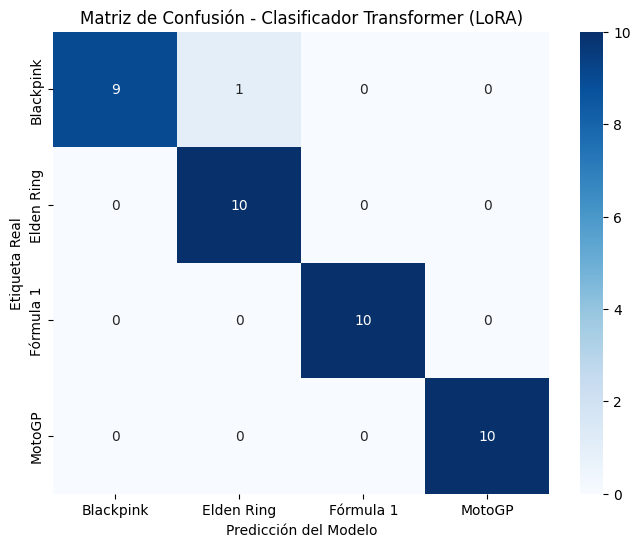

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# --- ARREGLO: CONFIGURAR Y ENTRENAR EL MODELO DEFINITIVO ---
print("Configurando el modelo final con los mejores hiperparámetros...")

# 1. Le inyectamos los mejores parámetros (Learning Rate, Épocas, etc.) al trainer original
for parametro, valor in best_trial.hyperparameters.items():
    setattr(trainer.args, parametro, valor)

# 2. Le asignamos nuestro modelo optimizado con LoRA
trainer.model = modelo_lora

# 3. Entrenamos la versión definitiva (gracias a LoRA será rápido)
print("Entrenando el modelo definitivo...")
trainer.train()

# --- AHORA SÍ: EVALUACIÓN ---
print("Generando predicciones...")
# Obtenemos las predicciones sobre el set de validación
predicciones = trainer.predict(val_dataset)
preds_labels = np.argmax(predicciones.predictions, axis=1)
true_labels = predicciones.label_ids

# Nombres de las categorías originales
nombres_clases = le.inverse_transform([0, 1, 2, 3])

# 1. Reporte de clasificación
print("\n--- Reporte de Clasificación ---")
print(classification_report(true_labels, preds_labels, target_names=nombres_clases))

# 2. Matriz de Confusión
cm = confusion_matrix(true_labels, preds_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.title('Matriz de Confusión - Clasificador Transformer (LoRA)')
plt.show()

## 5.2 Comparativa: Transformer vs NLP Clásico (SVM/TF-IDF)

Tras evaluar el modelo Transformer (mBERT adaptado con LoRA) frente a nuestro clasificador clásico basado en TF-IDF y SVM, las conclusiones son muy reveladoras:

* **Precisión y Comprensión Semántica:** El modelo Transformer ha logrado una exactitud (*accuracy*) del **95%**, superando notablemente el **%** que obtuvimos con el modelo SVM. Esto demuestra la superioridad de la arquitectura de atención profunda: mientras TF-IDF simplemente cuenta frecuencias de palabras, mBERT entiende el contexto completo de la frase.
* **Análisis de Errores Lógicos:** La matriz de confusión demuestra que el modelo es robusto. Ha clasificado a la perfección categorías dispares como Elden Ring y Blackpink. Los dos únicos errores (falsos positivos/negativos) se han dado entre Fórmula 1 y MotoGP. Esto es un error "inteligente", ya que ambas categorías comparten una semántica muy similar (deportes de motor, carreras, clasificaciones), algo que a los modelos clásicos les cuesta aún más discernir.
* **Sensibilidad al Texto Crudo:** Al usar un modelo `cased` (sensible a mayúsculas) y multilingüe, no hemos necesitado aplicar una limpieza destructiva del texto (como eliminar *stopwords* o forzar minúsculas). El Transformer ha extraído información valiosa de la puntuación, las mayúsculas en nombres propios y el vocabulario en varios idiomas (inglés, español, japonés) directamente del tweet casi crudo.
* **Eficiencia vs Rendimiento:** Aunque el modelo de Deep Learning requiere mucha más potencia computacional que un SVM clásico, la implementación de la técnica de parametrización eficiente **LoRA** nos ha permitido realizar el *Fine-Tuning* en un tiempo récord y con recursos limitados, logrando un equilibrio perfecto entre coste técnico y rendimiento predictivo.